## 셀 1: 의존성 준비
이 셀은 `fredapi`, `scikit-learn`, `matplotlib` 설치 여부를 확인하고 누락 시 설치를 시도합니다.


In [1]:
import importlib.util, subprocess, sys

required = ['fredapi', 'scikit-learn', 'matplotlib', 'scipy']
for pkg in required:
    module_name = 'sklearn' if pkg == 'scikit-learn' else pkg
    if importlib.util.find_spec(module_name) is None:
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
        except Exception as e:
            print(f'Package install skipped for {pkg}: {e}')


## 셀 2: 금리 데이터 로드 및 분기 곡선 비교
이 셀은 FRED에서 만기별 금리를 불러오고(실패 시 fallback), 최근 분기말들과 최신 곡선을 비교합니다.


data_source=fred, rows=6158, end_date=2026-03-18


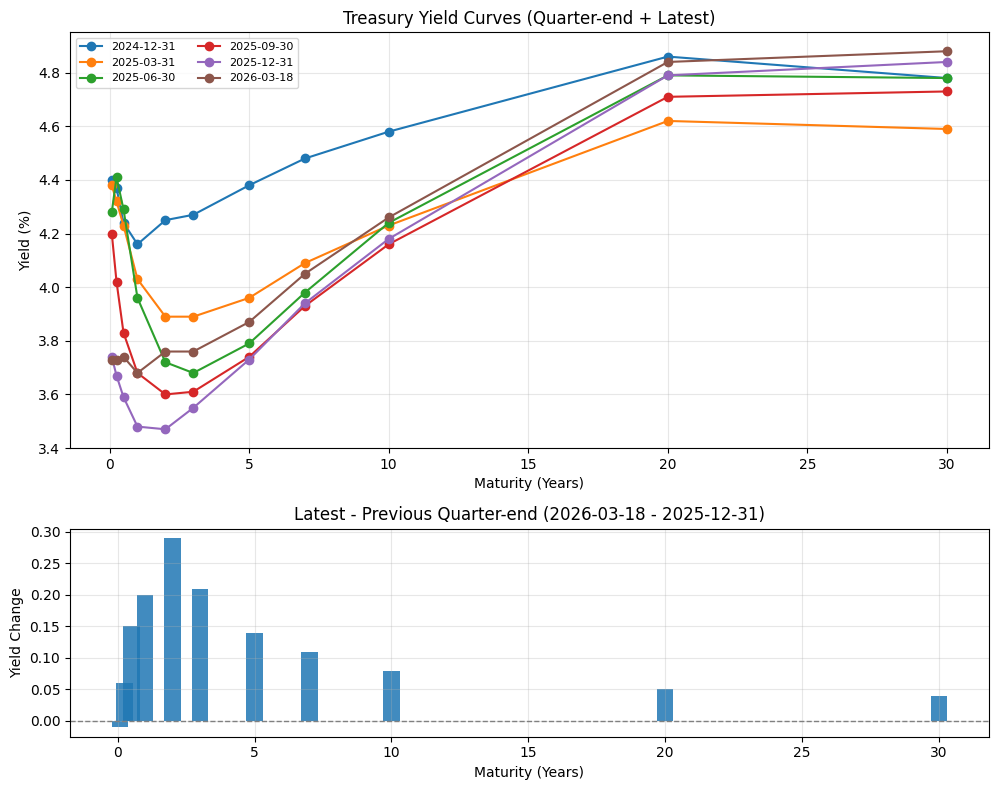

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline_common.notebook_data import load_yield_curve_df
from pipeline_common.notebook_models import select_quarter_snapshots

series_ids = ['DGS1MO','DGS3MO','DGS6MO','DGS1','DGS2','DGS3','DGS5','DGS7','DGS10','DGS20','DGS30']
maturities = np.array([0.08,0.25,0.5,1,2,3,5,7,10,20,30], dtype=float)

df, data_source = load_yield_curve_df(series_ids, start='2015-01-01')
selected_df = select_quarter_snapshots(df, n_quarters=5)
end_ts = selected_df.index[-1]

print(f'data_source={data_source}, rows={len(df)}, end_date={end_ts.date()}')

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios':[2,1]})
for d in selected_df.index:
    axes[0].plot(maturities, selected_df.loc[d].values, marker='o', label=d.strftime('%Y-%m-%d'))
axes[0].set_title('Treasury Yield Curves (Quarter-end + Latest)')
axes[0].set_xlabel('Maturity (Years)')
axes[0].set_ylabel('Yield (%)')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8, ncol=2)

if len(selected_df.index) > 1:
    ref_date = selected_df.index[-2]
    diff = selected_df.loc[end_ts].values - selected_df.loc[ref_date].values
    axes[1].bar(maturities, diff, width=0.6, color='tab:blue', alpha=0.85)
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[1].set_title(f'Latest - Previous Quarter-end ({end_ts.date()} - {ref_date.date()})')
    axes[1].set_xlabel('Maturity (Years)')
    axes[1].set_ylabel('Yield Change')
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 셀 3: 주 예측 모델(Ridge) 학습
이 셀은 최근 5영업일 입력으로 5영업일 후 금리곡선을 예측하는 Ridge 다중출력 모델을 학습/평가합니다.


In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

from pipeline_common.notebook_models import build_sequence_xy, flatten_sequence_X, time_split

SEQUENCE_LENGTH = 5
FORECAST_STEP = 5

df_model = df[series_ids].tail(1500).copy()
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_model.values)

X_seq, y = build_sequence_xy(scaled, sequence_length=SEQUENCE_LENGTH, forecast_step=FORECAST_STEP)
X = flatten_sequence_X(X_seq)

X_train, X_test, y_train, y_test = time_split(X, y, train_ratio=0.8)

main_model = MultiOutputRegressor(Ridge(alpha=1.0, random_state=42))
main_model.fit(X_train, y_train)
pred_test = main_model.predict(X_test)
main_test_mse = mean_squared_error(y_test, pred_test)
print(f'Ridge Test MSE (scaled): {main_test_mse:.8f}')

last_seq = scaled[-SEQUENCE_LENGTH:].reshape(1, -1)
pred_main_scaled = main_model.predict(last_seq)
pred_main_curve = scaler.inverse_transform(pred_main_scaled)[0]
latest_curve = df_model.iloc[-1].values
future_date = df_model.index[-1] + pd.offsets.BDay(FORECAST_STEP)


Ridge Test MSE (scaled): 0.00047026


## 셀 4: Nelson-Siegel 요인 기반 베이스라인
이 셀은 Nelson-Siegel 요인을 추정하고 요인 자기회귀로 곡선을 복원해 Ridge와 비교합니다.


In [4]:
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression

from pipeline_common.notebook_models import ns_curve

lam_grid = np.linspace(0.1, 2.0, 20)
best_lam, best_mse = 1.0, np.inf

for lam in lam_grid:
    errs = []
    for _, row in df_model.iterrows():
        yv = row.values.astype(float)
        try:
            popt, _ = curve_fit(lambda t,b0,b1,b2: ns_curve(t,b0,b1,b2,lam), maturities, yv, p0=[yv.mean(),-1,1], maxfev=5000)
            recon = ns_curve(maturities, *popt, lam)
            errs.append(np.mean((yv - recon)**2))
        except Exception:
            continue
    if errs:
        mse = float(np.mean(errs))
        if mse < best_mse:
            best_mse, best_lam = mse, lam

betas = []
for _, row in df_model.iterrows():
    yv = row.values.astype(float)
    try:
        p, _ = curve_fit(lambda t,b0,b1,b2: ns_curve(t,b0,b1,b2,best_lam), maturities, yv, p0=[yv.mean(),-1,1], maxfev=8000)
        betas.append(p)
    except Exception:
        betas.append([np.nan, np.nan, np.nan])

betas_df = pd.DataFrame(betas, index=df_model.index, columns=['beta0','beta1','beta2']).dropna()

# simple AR(1) per factor
beta_fore = []
for c in betas_df.columns:
    s = betas_df[c].values
    Xb = s[:-1].reshape(-1,1)
    yb = s[1:]
    m = LinearRegression().fit(Xb, yb)
    b_next = m.predict(np.array([[s[-1]]]))[0]
    beta_fore.append(b_next)

beta_fore = np.array(beta_fore)
pred_ns_curve = ns_curve(maturities, beta_fore[0], beta_fore[1], beta_fore[2], best_lam)
print(f'NS baseline lambda={best_lam:.3f}, in-sample mse={best_mse:.6f}')


NS baseline lambda=0.500, in-sample mse=0.013792


## 셀 5: 모델 벤치마크
이 셀은 Linear/Ridge/ElasticNet/RandomForest를 동일 조건에서 백테스트하고 성능을 표로 정리합니다.


In [5]:
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor

bench_models = {
    'Linear': MultiOutputRegressor(LinearRegression()),
    'Ridge': MultiOutputRegressor(Ridge(alpha=1.0, random_state=42)),
    'ElasticNet': MultiOutputRegressor(ElasticNet(alpha=0.0005, l1_ratio=0.3, random_state=42, max_iter=5000)),
    'RandomForest': MultiOutputRegressor(RandomForestRegressor(n_estimators=60, max_depth=6, random_state=42, n_jobs=1)),
}

bench_rows = []
for name, m in bench_models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    mse = mean_squared_error(y_test, p)
    bench_rows.append({'Model': name, 'Test_MSE': mse})

benchmark_df = pd.DataFrame(bench_rows).sort_values('Test_MSE').reset_index(drop=True)
print('Benchmark results:')
print(benchmark_df)


Benchmark results:
          Model  Test_MSE
0        Linear  0.000429
1         Ridge  0.000470
2    ElasticNet  0.000472
3  RandomForest  0.002154


## 셀 6: 최종 비교 시각화
이 셀은 최신 곡선, 주 모델 예측, NS 베이스라인을 한 번에 비교하고 변화량을 시각화합니다.


Forecast target date: 2026-03-25
    Maturity  Latest  Ridge_Forecast(+5bd)  NS_Baseline  Ridge-Actual  \
0       0.08    3.73              3.790419     3.798586      0.060419   
1       0.25    3.73              3.753188     3.757134      0.023188   
2       0.50    3.74              3.728939     3.709424     -0.011061   
3       1.00    3.68              3.699591     3.652895      0.019591   
4       2.00    3.76              3.680611     3.646234     -0.079389   
5       3.00    3.76              3.689511     3.717763     -0.070489   
6       5.00    3.87              3.868268     3.934327     -0.001732   
7       7.00    4.05              4.108557     4.142850      0.058557   
8      10.00    4.26              4.327364     4.377461      0.067364   
9      20.00    4.84              4.798566     4.728283     -0.041434   
10     30.00    4.88              4.717373     4.852211     -0.162627   

    NS-Actual  
0    0.068586  
1    0.027134  
2   -0.030576  
3   -0.027105  
4   -0.113

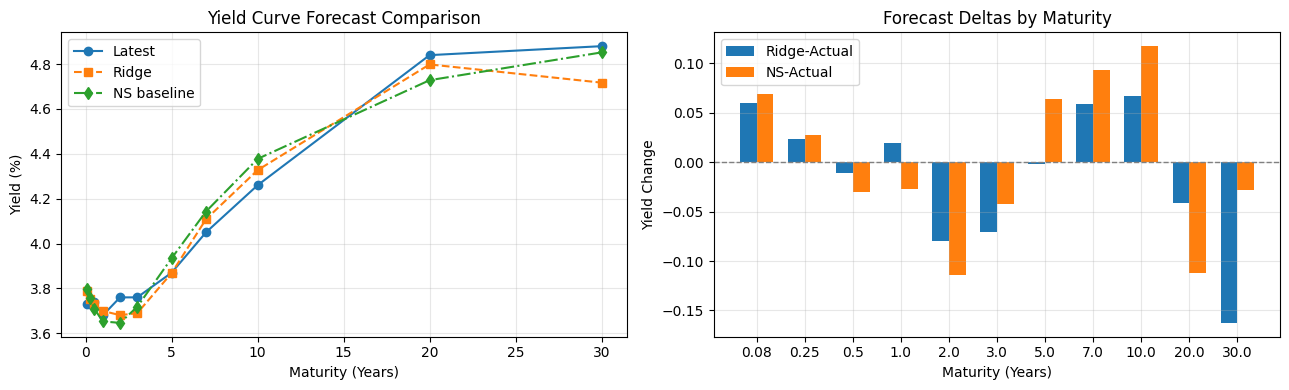

In [6]:
compare_df = pd.DataFrame({
    'Maturity': maturities,
    'Latest': latest_curve,
    'Ridge_Forecast(+5bd)': pred_main_curve,
    'NS_Baseline': pred_ns_curve,
})
compare_df['Ridge-Actual'] = compare_df['Ridge_Forecast(+5bd)'] - compare_df['Latest']
compare_df['NS-Actual'] = compare_df['NS_Baseline'] - compare_df['Latest']

print(f'Forecast target date: {future_date.date()}')
print(compare_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(compare_df['Maturity'], compare_df['Latest'], 'o-', label='Latest')
axes[0].plot(compare_df['Maturity'], compare_df['Ridge_Forecast(+5bd)'], 's--', label='Ridge')
axes[0].plot(compare_df['Maturity'], compare_df['NS_Baseline'], 'd-.', label='NS baseline')
axes[0].set_title('Yield Curve Forecast Comparison')
axes[0].set_xlabel('Maturity (Years)')
axes[0].set_ylabel('Yield (%)')
axes[0].grid(alpha=0.3)
axes[0].legend()

w=0.35
x = np.arange(len(compare_df))
axes[1].bar(x-w/2, compare_df['Ridge-Actual'], width=w, label='Ridge-Actual')
axes[1].bar(x+w/2, compare_df['NS-Actual'], width=w, label='NS-Actual')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(compare_df['Maturity'])
axes[1].set_title('Forecast Deltas by Maturity')
axes[1].set_xlabel('Maturity (Years)')
axes[1].set_ylabel('Yield Change')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
